In [5]:
from pathlib import Path
import sys
import traceback
from tqdm import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.axes import Axes
import spikeinterface as si 
import cv2
import data_analysis.mea_analysis as mea
from data_analysis.plotting import get_c_map_colors
SAMPLING_RATE = mea.SAMPLING_RATE

In [6]:
BRW_BASE_FOLDER = Path("/media/ferdinand-forberger/RawDataBackUp")
MAIN_FOLDER = Path("/media/ferdinand-forberger/Seagate Portable Drive")
df_overview = mea.get_overview(MAIN_FOLDER)
df_overview = df_overview[df_overview["sles_saved"]==True]
df_overview.reset_index(inplace=True, drop=True)
df_overview["image_path"]= df_overview["folder_path"].astype(str) + "/org_image.png"
df_overview["mask_path"] = df_overview["folder_path"].astype(str) + "/mask.png"

In [7]:
def propagation_plot(indices_to_plot: list, 
                     axes: Axes, 
                     org_img: np.ndarray, 
                     filtered_first_spikes : list,
                     filtered_chans : list):
    for i, j in enumerate(indices_to_plot):
        
        st = filtered_first_spikes[j]
        chans = filtered_chans[j].copy()
        heatmap = np.full(4096, np.nan)
        heatmap[chans] = st
        heatmap = heatmap.reshape(64,64)
        org_img_shape = org_img.shape[:2]
        heatmap = cv2.resize(heatmap,org_img_shape, interpolation=cv2.INTER_NEAREST)
        axes[i].imshow(org_img)
        axes[i].imshow(heatmap)
        axes[i].set_axis_off()

        cbar = plt.colorbar(axes[i].images[1], ax=axes[i], shrink=0.5, pad=0.01)
        cbar.set_label("First spike time [s]", rotation=270, labelpad=15)


In [8]:
from data_analysis.mea_analysis import chans_to_coords, velocity_field

origins = []
org_imgs = []
filtered_first_spikes_list = []
filtered_chans_list = []
speeds = []
speeds_arr_based = []
for i, row in tqdm(df_overview.iterrows()):
    print(f"Processing {row['folder_path']} ({i+1}/{len(df_overview)})")
    st_df, st, clu, best_cha_st, vectorized_map =  mea.get_stdf(row["folder_path"])
    burst_json_path = Path(row["folder_path"]) / "burst_params.json"
    sles = np.load(row["sle_path"])
    image_path = Path(row["folder_path"]) / Path("org_image.png")
    org_img = cv2.imread(image_path)
    org_img = cv2.cvtColor(org_img, cv2.COLOR_BGR2RGB)    
    res = mea.filter_spikes_find_origin(sles=sles,
                                                st=st,
                                                clu=clu,
                                                cluster_to_channel_map=vectorized_map, 
                                                burst_json_path=burst_json_path, 
                                                folder_path=row["folder_path"])
    estimated_SLE_orgins, first_spikes, unique_chans_list, filtered_first_spikes, filtered_chans, chan_subsets = res
    origins.append(estimated_SLE_orgins)
    org_imgs.append(org_img)
    filtered_first_spikes_list.append(filtered_first_spikes)
    filtered_chans_list.append(filtered_chans)

    recording_speeds = []
    recording_speeds_arrs = []
    num_points = [len(fs) for fs in filtered_first_spikes]
    for i in range(len(filtered_chans)):
        try:
            
            x_coords, y_coords = chans_to_coords(filtered_chans[i])
            x_coords = x_coords / 64 * 3.78 #in mm
            y_coords = y_coords / 64 * 3.78 #

            speed, result_dict = velocity_field(x_coords, y_coords, filtered_first_spikes[i])
            recording_speeds_arrs.append(speed)
            grid_X = result_dict["grid_X"]
            grid_Y = result_dict["grid_Y"]
            time_surface = result_dict["time_surface"]
            dir_x = result_dict["dir_x"]
            dir_y = result_dict["dir_y"]
            
            median_speed = np.nanmedian(speed)
            recording_speeds.append(median_speed)
        except Exception as e:
            print(f"Error calculating velocity field for recording {row['folder_path']}, burst {i}: {e}")
            traceback.print_exc()
            recording_speeds.append(np.nan)
            recording_speeds_arrs.append(np.full((200,200), np.nan))
    recording_speeds_arrs = np.array(recording_speeds_arrs)
    median_speeds_arr = np.nanmedian(recording_speeds_arrs, axis=0)
    median_speeds_arr[np.sum(~np.isnan(recording_speeds_arrs), axis=0)<recording_speeds_arrs.shape[0]*0.4] = np.nan
    median_speeds_arr_based = np.nanmedian(median_speeds_arr)
    speeds_arr_based.append(median_speeds_arr_based)
    speeds.append(np.nanmedian(recording_speeds))
    


0it [00:00, ?it/s]

Processing /media/ferdinand-forberger/Seagate Portable Drive/8561_3 (1/22)
Comparison of Labels (Original vs. Changed)
KSLabel agreement: 408, disagreement: 0
Number of good clusters (Original): 121
Number of good clusters (Changed): 121
-------------------------------------------------------
Comparison of Labels (Original vs. Changed)
KSLabel agreement: 408, disagreement: 0
Number of good clusters (Original): 121
Number of good clusters (Changed): 121
-------------------------------------------------------


100%|██████████| 408/408 [00:00<00:00, 3461.92it/s]
/tmp/ipykernel_13009/3048504371.py:57: RuntimeWarning: All-NaN slice encountered
  median_speeds_arr = np.nanmedian(recording_speeds_arrs, axis=0)
1it [00:03,  3.87s/it]

Processing /media/ferdinand-forberger/Seagate Portable Drive/8561_5 (2/22)
Comparison of Labels (Original vs. Changed)
KSLabel agreement: 554, disagreement: 0
Number of good clusters (Original): 119
Number of good clusters (Changed): 119
-------------------------------------------------------
Comparison of Labels (Original vs. Changed)
KSLabel agreement: 554, disagreement: 0
Number of good clusters (Original): 119
Number of good clusters (Changed): 119
-------------------------------------------------------


100%|██████████| 554/554 [00:00<00:00, 1390.30it/s]
/tmp/ipykernel_13009/3048504371.py:57: RuntimeWarning: All-NaN slice encountered
  median_speeds_arr = np.nanmedian(recording_speeds_arrs, axis=0)
2it [00:07,  3.85s/it]

...

100%|██████████| 558/558 [00:00<00:00, 1271.04it/s]
/tmp/ipykernel_13009/3048504371.py:57: RuntimeWarning: All-NaN slice encountered
  median_speeds_arr = np.nanmedian(recording_speeds_arrs, axis=0)
20it [01:25,  4.33s/it]

Processing /media/ferdinand-forberger/Seagate Portable Drive/8606_5 (21/22)
Comparison of Labels (Original vs. Changed)
KSLabel agreement: 450, disagreement: 0
Number of good clusters (Original): 91
Number of good clusters (Changed): 91
-------------------------------------------------------
Comparison of Labels (Original vs. Changed)
KSLabel agreement: 450, disagreement: 0
Number of good clusters (Original): 91
Number of good clusters (Changed): 91
-------------------------------------------------------


100%|██████████| 450/450 [00:00<00:00, 770.05it/s]
/tmp/ipykernel_13009/3048504371.py:57: RuntimeWarning: All-NaN slice encountered
  median_speeds_arr = np.nanmedian(recording_speeds_arrs, axis=0)
21it [01:32,  4.95s/it]

Processing /media/ferdinand-forberger/Seagate Portable Drive/8606_6 (22/22)
Comparison of Labels (Original vs. Changed)
KSLabel agreement: 323, disagreement: 0
Number of good clusters (Original): 55
Number of good clusters (Changed): 55
-------------------------------------------------------
Comparison of Labels (Original vs. Changed)
KSLabel agreement: 323, disagreement: 0
Number of good clusters (Original): 55
Number of good clusters (Changed): 55
-------------------------------------------------------


100%|██████████| 323/323 [00:00<00:00, 947.24it/s]
/tmp/ipykernel_13009/3048504371.py:57: RuntimeWarning: All-NaN slice encountered
  median_speeds_arr = np.nanmedian(recording_speeds_arrs, axis=0)
22it [01:37,  4.42s/it]


In [9]:
df_metadata = pd.read_excel("/media/ferdinand-forberger/RawDataBackUp/meta_data_file.xlsx")
df_metadata["folder"] = df_metadata["animal_number"].astype(str) + "_" + df_metadata["slice_number"].astype(str)
df_overview = pd.merge(df_overview, df_metadata, left_on="folder", right_on="folder", how="left")

In [10]:
from scipy.stats import mannwhitneyu

In [11]:
df_overview["v_arr_based"] = speeds_arr_based
df_overview["velocity"] = speeds

In [12]:
result = mannwhitneyu(df_overview[df_overview["group"]=="Sham"]["velocity"].dropna(), 
                      df_overview[df_overview["group"]=="Tumor"]["velocity"].dropna())
result

MannwhitneyuResult(statistic=np.float64(89.0), pvalue=np.float64(0.06021250140377914))

<Axes: xlabel='group', ylabel='velocity'>

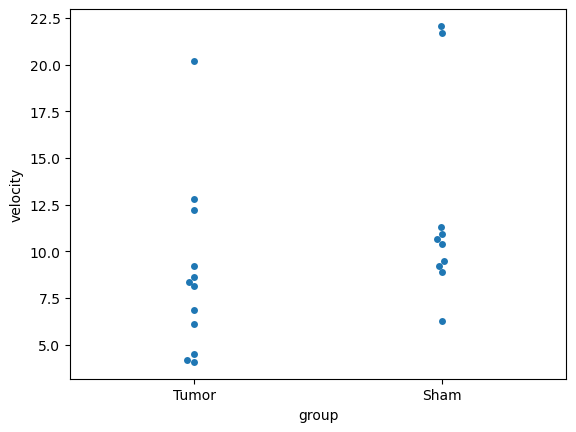

In [13]:
import seaborn as sns
sns.swarmplot(data=df_overview, x="group", y="velocity")

In [15]:
velocity_df = df_overview[["folder", "group", "velocity"]]
velocity_df.to_excel("data/velocity_data.xlsx")